<a href="https://colab.research.google.com/github/devigorll/projeto_estrutura/blob/main/projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Projeto de análise de dados - Brasileirão 2024**


---



In [167]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import os
import csv
import seaborn as sns
import matplotlib.pyplot as plt

In [168]:
# Importando arquivo csv direto do Kaggle

import kagglehub
path = kagglehub.dataset_download("fabioschirmann/brasileiro-2024-srie-a-dataset")

# Lista os arquivos da pasta
arquivos = os.listdir(path)
print(arquivos)

# Exemplo: pegar o primeiro arquivo CSV encontrado
arquivo_csv = [arq for arq in arquivos if arq.endswith(".csv")][0]

# Caminho completo do arquivo
caminho_arquivo = os.path.join(path, arquivo_csv)

# Lendo o dataset
df = pd.read_csv(caminho_arquivo)
df.columns = ["DATA", "HORARIO", "MANDANTE", "PLACAR", "VISITANTE", "PUBLICO", "ESTADIO"]
df

Using Colab cache for faster access to the 'brasileiro-2024-srie-a-dataset' dataset.
['Brasileiro 2024 (Srie A) - Dataset - Final.csv', 'Brasileiro 2024 (Srie A) - Dataset.csv']


,DATA,HORARIO,MANDANTE,PLACAR,VISITANTE,PUBLICO,ESTADIO
0,2024-04-13,18:30,Internacional,2–1,Bahia,"19,103",Estádio José Pinheiro Borba
1,2024-04-14,16:00,Ath Paranaense,4–0,Cuiabá,"21,388",Ligga Arena
2,2024-04-14,16:00,Vasco da Gama,2–1,Grêmio,"17,722",Estádio Club de Regatas Vasco da Gama
3,2024-04-14,16:00,Corinthians,0–0,Atlético Mineiro,"44,285",Neo Química Arena
4,2024-04-14,16:00,Atl Goianiense,1–2,Flamengo,"31,617",Estádio do Governo do Estado de Goiás
...,...,...,...,...,...,...,...
374,2024-12-08,16:00,Grêmio,0–3,Corinthians,"42,945",Arena do Grêmio
375,2024-12-08,16:00,Palmeiras,0–1,Fluminense,"34,571",Allianz Parque
376,2024-12-08,16:00,Bahia,2–0,Atl Goianiense,"48,476",Itaipava Arena Fonte Nova
377,2024-12-08,16:00,Juventude,0–1,Cruzeiro,"13,518",Estádio Alfredo Jaconi


In [169]:
# Criando arquivo csv | Futuramente irei salvar as alterações da tabela noa arquivo csv

with open("base.csv", "w", newline = "", encoding = "utf-8") as arquivo_csv:
  escritor = csv.writer(arquivo_csv)
  escritor.writerow(df.columns)
  escritor.writerows(df.values)

In [170]:
# Carregando arquivo csv
base = pd.read_csv("/content/base.csv")
base

,DATA,HORARIO,MANDANTE,PLACAR,VISITANTE,PUBLICO,ESTADIO
0,2024-04-13,18:30,Internacional,2–1,Bahia,"19,103",Estádio José Pinheiro Borba
1,2024-04-14,16:00,Ath Paranaense,4–0,Cuiabá,"21,388",Ligga Arena
2,2024-04-14,16:00,Vasco da Gama,2–1,Grêmio,"17,722",Estádio Club de Regatas Vasco da Gama
3,2024-04-14,16:00,Corinthians,0–0,Atlético Mineiro,"44,285",Neo Química Arena
4,2024-04-14,16:00,Atl Goianiense,1–2,Flamengo,"31,617",Estádio do Governo do Estado de Goiás
...,...,...,...,...,...,...,...
374,2024-12-08,16:00,Grêmio,0–3,Corinthians,"42,945",Arena do Grêmio
375,2024-12-08,16:00,Palmeiras,0–1,Fluminense,"34,571",Allianz Parque
376,2024-12-08,16:00,Bahia,2–0,Atl Goianiense,"48,476",Itaipava Arena Fonte Nova
377,2024-12-08,16:00,Juventude,0–1,Cruzeiro,"13,518",Estádio Alfredo Jaconi


In [171]:
# Média gols por mandante

gols_mandante = np.int64(base["PLACAR"].str[0])
media_gols_mandantes = (round(gols_mandante.mean(), 2))

In [172]:
# Média de gols visitande

gols_visitante = np.int64(base["PLACAR"].str[0])
media_gols_visitante = (round(gols_visitante.mean(), 2))

In [173]:
# Média de gols campeonato

media_gols_campeonato = np.mean(media_gols_visitante + media_gols_mandantes)

In [174]:
# Gols por jogo

base["GOLS MANDANTE"] = np.int64(base["PLACAR"].str[0])
base["GOLS VISITANTE"] = np.int64(base["PLACAR"].str[2])
base["GOLS POR JOGO"] = (base["GOLS MANDANTE"] + base["GOLS VISITANTE"])
base

,DATA,HORARIO,MANDANTE,PLACAR,VISITANTE,PUBLICO,ESTADIO,GOLS MANDANTE,GOLS VISITANTE,GOLS POR JOGO
0,2024-04-13,18:30,Internacional,2–1,Bahia,"19,103",Estádio José Pinheiro Borba,2,1,3
1,2024-04-14,16:00,Ath Paranaense,4–0,Cuiabá,"21,388",Ligga Arena,4,0,4
2,2024-04-14,16:00,Vasco da Gama,2–1,Grêmio,"17,722",Estádio Club de Regatas Vasco da Gama,2,1,3
3,2024-04-14,16:00,Corinthians,0–0,Atlético Mineiro,"44,285",Neo Química Arena,0,0,0
4,2024-04-14,16:00,Atl Goianiense,1–2,Flamengo,"31,617",Estádio do Governo do Estado de Goiás,1,2,3
...,...,...,...,...,...,...,...,...,...,...
374,2024-12-08,16:00,Grêmio,0–3,Corinthians,"42,945",Arena do Grêmio,0,3,3
375,2024-12-08,16:00,Palmeiras,0–1,Fluminense,"34,571",Allianz Parque,0,1,1
376,2024-12-08,16:00,Bahia,2–0,Atl Goianiense,"48,476",Itaipava Arena Fonte Nova,2,0,2
377,2024-12-08,16:00,Juventude,0–1,Cruzeiro,"13,518",Estádio Alfredo Jaconi,0,1,1


In [175]:
base["HORA"] = base["HORARIO"].str[:2]
base["HORA"] = np.int64(base["HORA"])

In [176]:
base[base["GOLS POR JOGO"] == max(base["GOLS POR JOGO"])]

,DATA,HORARIO,MANDANTE,PLACAR,VISITANTE,PUBLICO,ESTADIO,GOLS MANDANTE,GOLS VISITANTE,GOLS POR JOGO,HORA
294,2024-10-20,20:00,Juventude,3–5,Palmeiras,"10,102",Estádio Alfredo Jaconi,3,5,8,20


In [177]:
gols_tarde = base[base["HORA"] < 18]["GOLS POR JOGO"].sum()
gols_tarde

np.int64(305)

In [178]:
gols_noite = base[base["HORA"] > 18]["GOLS POR JOGO"].sum()
gols_noite

np.int64(440)

<Axes: xlabel='HORA'>

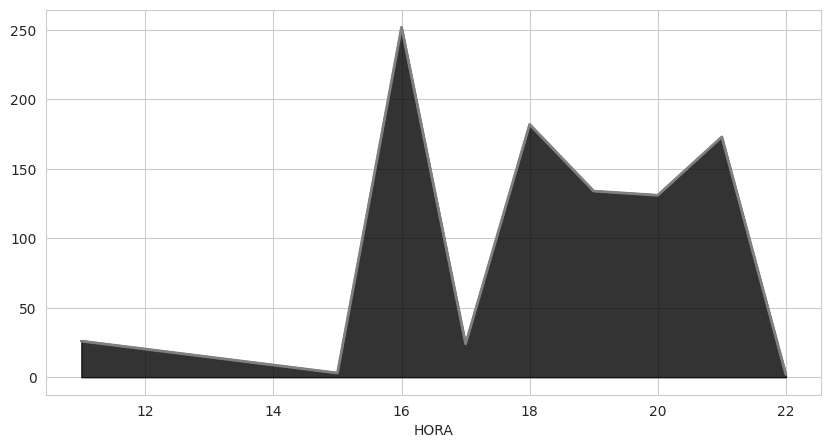

In [179]:
# gols por hora

gols_por_hora = base.groupby("HORA")["GOLS POR JOGO"].sum()


plt.figure(figsize = (10,5))

plt.fill_between(gols_por_hora.index, gols_por_hora.values, color = "black", facecolors= "black", alpha = 0.80)
plt.plot(gols_por_hora.index, gols_por_hora.values)

sns.lineplot(x = gols_por_hora.index, y = gols_por_hora.values, linewidth = 2, color = "gray")

In [180]:
# Reogarnizando sequência de colunas

base = base [
    [
        "DATA",
        "HORARIO",
        "HORA",
        "MANDANTE",
        "PLACAR",
        "VISITANTE",
        "PUBLICO",
        "ESTADIO",
        "GOLS POR JOGO",
        "GOLS MANDANTE",
        "GOLS VISITANTE"
    ]
]

base

,DATA,HORARIO,HORA,MANDANTE,PLACAR,VISITANTE,PUBLICO,ESTADIO,GOLS POR JOGO,GOLS MANDANTE,GOLS VISITANTE
0,2024-04-13,18:30,18,Internacional,2–1,Bahia,"19,103",Estádio José Pinheiro Borba,3,2,1
1,2024-04-14,16:00,16,Ath Paranaense,4–0,Cuiabá,"21,388",Ligga Arena,4,4,0
2,2024-04-14,16:00,16,Vasco da Gama,2–1,Grêmio,"17,722",Estádio Club de Regatas Vasco da Gama,3,2,1
3,2024-04-14,16:00,16,Corinthians,0–0,Atlético Mineiro,"44,285",Neo Química Arena,0,0,0
4,2024-04-14,16:00,16,Atl Goianiense,1–2,Flamengo,"31,617",Estádio do Governo do Estado de Goiás,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...
374,2024-12-08,16:00,16,Grêmio,0–3,Corinthians,"42,945",Arena do Grêmio,3,0,3
375,2024-12-08,16:00,16,Palmeiras,0–1,Fluminense,"34,571",Allianz Parque,1,0,1
376,2024-12-08,16:00,16,Bahia,2–0,Atl Goianiense,"48,476",Itaipava Arena Fonte Nova,2,2,0
377,2024-12-08,16:00,16,Juventude,0–1,Cruzeiro,"13,518",Estádio Alfredo Jaconi,1,0,1


In [181]:
base.to_csv("base_tratada.csv", index = False, encoding='utf-8-sig')

In [182]:
base_tratada = pd.read_csv("/content/base_tratada.csv")

# Tabela mandante
mandante = pd.DataFrame({
    'time': base_tratada['MANDANTE'],
    'gols_pro': base_tratada['GOLS MANDANTE'],
    'gols_contra': base_tratada['GOLS VISITANTE']
})

# Criando coluna de pontos
mandante['pontos'] = mandante.apply(
    # Calculando ponntuação
    lambda x: 3 if x['gols_pro'] > x['gols_contra']
    else 1 if x['gols_pro'] == x['gols_contra']
    else 0,
    axis=1
)

# Criando colunas de vitória, empate e derrota

# Vitória
mandante['vitorias'] = (
    mandante['gols_pro'] > mandante['gols_contra']
).astype(int)

# Empate
mandante['empates'] = (
    mandante['gols_pro'] == mandante['gols_contra']
).astype(int)

# Derrota
mandante['derrotas'] = (
    mandante['gols_pro'] < mandante['gols_contra']
).astype(int)

# jogos
mandante['jogos'] = 1



# Tabela Visitante


visitante = pd.DataFrame({
    'time': base_tratada['VISITANTE'],
    'gols_pro': base_tratada['GOLS VISITANTE'],
    'gols_contra': base_tratada['GOLS MANDANTE']
})

# pontos
visitante['pontos'] = visitante.apply(
    lambda x: 3 if x['gols_pro'] > x['gols_contra']
    else 1 if x['gols_pro'] == x['gols_contra']
    else 0,
    axis=1
)

visitante['vitorias'] = (
    visitante['gols_pro'] > visitante['gols_contra']
).astype(int)

visitante['empates'] = (
    visitante['gols_pro'] == visitante['gols_contra']
).astype(int)

visitante['derrotas'] = (
    visitante['gols_pro'] < visitante['gols_contra']
).astype(int)

visitante['jogos'] = 1


# Juntando as tabelas

tabela = pd.concat([mandante, visitante])

# Saldo de gols
tabela['saldo'] = tabela['gols_pro'] - tabela['gols_contra']


# Tabea final

classificacao = (
    tabela.groupby('time').sum().sort_values(by=['pontos', 'vitorias', 'saldo', 'gols_pro'],ascending=False).reset_index()
)

# Reorganizando colunas
classificacao = classificacao[
    [
        'time',
        'pontos',
        'jogos',
        'vitorias',
        'empates',
        'derrotas',
        'gols_pro',
        'gols_contra',
        'saldo'
    ]
]

# Posição
classificacao.index += 1
classificacao.index.name = 'posicao'

classificacao.columns = classificacao.columns.str.upper()

classificacao.to_csv("classificacao.csv", index=False)

classificacao

,TIME,PONTOS,JOGOS,VITORIAS,EMPATES,DERROTAS,GOLS_PRO,GOLS_CONTRA,SALDO
posicao,,,,,,,,,
1,Botafogo (RJ),79,38,23,10,5,59,29,30
2,Palmeiras,73,38,22,7,9,60,33,27
3,Flamengo,70,38,20,10,8,61,42,19
4,Fortaleza,68,38,19,11,8,53,39,14
5,Internacional,65,38,18,11,9,53,36,17
6,São Paulo,59,38,17,8,13,53,43,10
7,Corinthians,56,38,15,11,12,54,45,9
8,Bahia,53,38,15,8,15,49,49,0
9,Cruzeiro,52,38,14,10,14,43,41,2


In [183]:
base_tratada

,DATA,HORARIO,HORA,MANDANTE,PLACAR,VISITANTE,PUBLICO,ESTADIO,GOLS POR JOGO,GOLS MANDANTE,GOLS VISITANTE
0,2024-04-13,18:30,18,Internacional,2–1,Bahia,"19,103",Estádio José Pinheiro Borba,3,2,1
1,2024-04-14,16:00,16,Ath Paranaense,4–0,Cuiabá,"21,388",Ligga Arena,4,4,0
2,2024-04-14,16:00,16,Vasco da Gama,2–1,Grêmio,"17,722",Estádio Club de Regatas Vasco da Gama,3,2,1
3,2024-04-14,16:00,16,Corinthians,0–0,Atlético Mineiro,"44,285",Neo Química Arena,0,0,0
4,2024-04-14,16:00,16,Atl Goianiense,1–2,Flamengo,"31,617",Estádio do Governo do Estado de Goiás,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...
374,2024-12-08,16:00,16,Grêmio,0–3,Corinthians,"42,945",Arena do Grêmio,3,0,3
375,2024-12-08,16:00,16,Palmeiras,0–1,Fluminense,"34,571",Allianz Parque,1,0,1
376,2024-12-08,16:00,16,Bahia,2–0,Atl Goianiense,"48,476",Itaipava Arena Fonte Nova,2,2,0
377,2024-12-08,16:00,16,Juventude,0–1,Cruzeiro,"13,518",Estádio Alfredo Jaconi,1,0,1




---



Valores que deverção aparecer no dashboard em StreamLit:

Média de gols por partida: 2.82
Média de gols por mandante: 1.41
Média de gols por visitante: 1.41
Gerar gráfico comparando vitória mandante X Visitante 




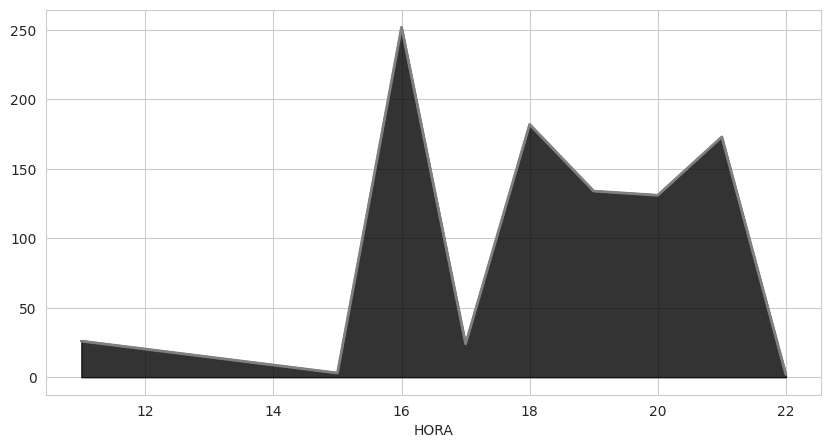

,TIME,PONTOS,JOGOS,VITORIAS,EMPATES,DERROTAS,GOLS_PRO,GOLS_CONTRA,SALDO
posicao,,,,,,,,,
1,Botafogo (RJ),79,38,23,10,5,59,29,30
2,Palmeiras,73,38,22,7,9,60,33,27
3,Flamengo,70,38,20,10,8,61,42,19
4,Fortaleza,68,38,19,11,8,53,39,14
5,Internacional,65,38,18,11,9,53,36,17
6,São Paulo,59,38,17,8,13,53,43,10
7,Corinthians,56,38,15,11,12,54,45,9
8,Bahia,53,38,15,8,15,49,49,0
9,Cruzeiro,52,38,14,10,14,43,41,2


In [184]:
print(f"Média de gols por partida: {media_gols_campeonato}")
print(f"Média de gols por mandante: {media_gols_mandantes}")
print(f"Média de gols por visitante: {media_gols_visitante}")
print(f"Gerar gráfico comparando vitória mandante X Visitante \n\n")

plt.figure(figsize = (10,5))

plt.fill_between(gols_por_hora.index, gols_por_hora.values, color = "black", facecolors= "black", alpha = 0.80)
plt.plot(gols_por_hora.index, gols_por_hora.values)

sns.lineplot(x = gols_por_hora.index, y = gols_por_hora.values, linewidth = 2, color = "gray")

plt.show()

classificacao

In [ ]:
# Instalando a biblioteca na minha máquina virtual

!pip install -q streamlit
!npm install -g localtunnel

In [ ]:
ip = !wget -qO- ipv4.icanhazip.com
print(f"IP de acesso a págona Web: {ip[0]}")

IP de acesso a págona Web: 35.188.230.89


In [ ]:
%%writefile app.py
import streamlit as st

st.title("Olá Igor")

Overwriting app.py
